In [40]:
# Wildfire Early Warning and resource allocation
## 204.1 assessment warner

#Dataset: UCI Forest Fires (Cortez and morais, 2007), montesinho park, portugal

## Task1: understanding disaster data and challenges

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize


sns.set_style("whitegrid")
RANDOM_STATE = 42

Load and inspect

In [42]:
data = pd.read_csv('forestfires.csv')
print(data.shape)
print(data.head())
print(data.info())
print(data.isnull().sum()) #chcek for missing values

(517, 13)
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null 

No missing values across all 517 rows, ready to continue



Target skew and severity scale


In [43]:
data['area_log'] = np.log1p(data['area'])
print(f"Area skew before transform: {data['area'].skew():.2f}")
print(f"Area skew after transform:  {data['area_log'].skew():.2f}")

Area skew before transform: 12.85
Area skew after transform:  1.22


In [44]:
# r area==0 straight to 'Low' - which is the correct real word meaning
#  this means that the fire was contained and never got to spread
#  which is a different category to a fire that did spread not just a low value on the same continuum
# the quantile-split only the non zero fires into the remaining 3 classes so that...
# medium, high and extreme stay balanced agaisnt each other

nonzero_log = data.loc[data['area_log'] > 0, 'area_log']
q1, q2 = nonzero_log.quantile([1/3, 2/3])

def classify_severity(x):
    if x == 0:
        return 'Low'
    elif x <= q1:
        return 'Medium'
    elif x <= q2:
        return 'High'
    else:
        return 'Extreme'

data['severity_labels'] = data['area_log'].apply(classify_severity)
print(data['severity_labels'].value_counts())


severity_labels
Low        247
Medium      90
High        90
Extreme     90
Name: count, dtype: int64


EDA visualisations

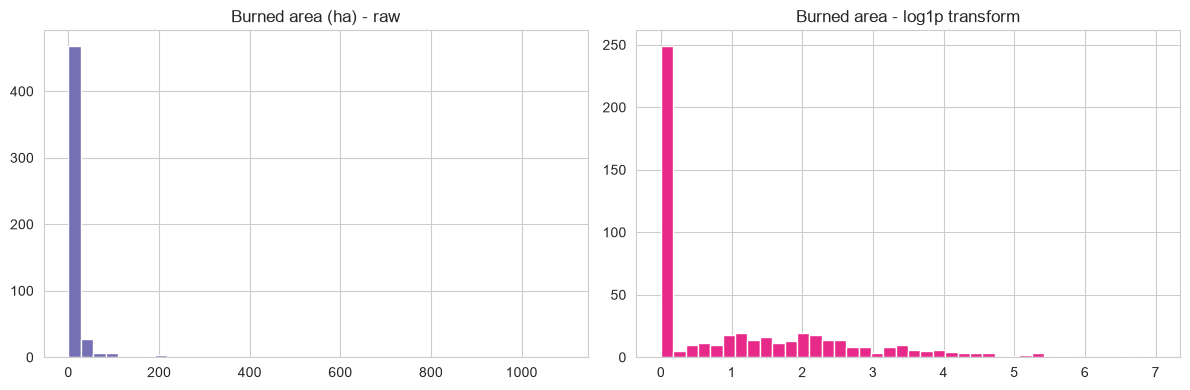

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data['area'], bins=40, color='#7570b3')
axes[0].set_title("Burned area (ha) - raw")
axes[1].hist(data['area_log'], bins=40, color='#e7298a')
axes[1].set_title("Burned area - log1p transform")
plt.tight_layout()
plt.savefig("fig_area_distribution.png")
plt.show()


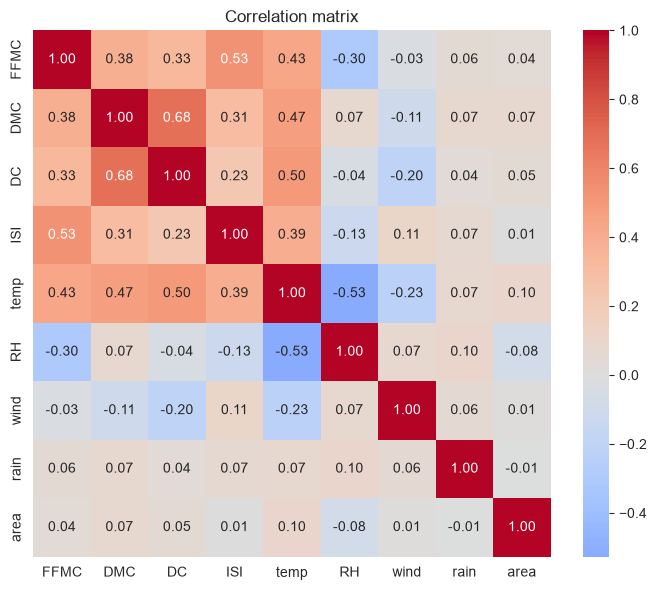

In [46]:
num_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
corr = data[num_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("fig_correlation.png")
plt.show()

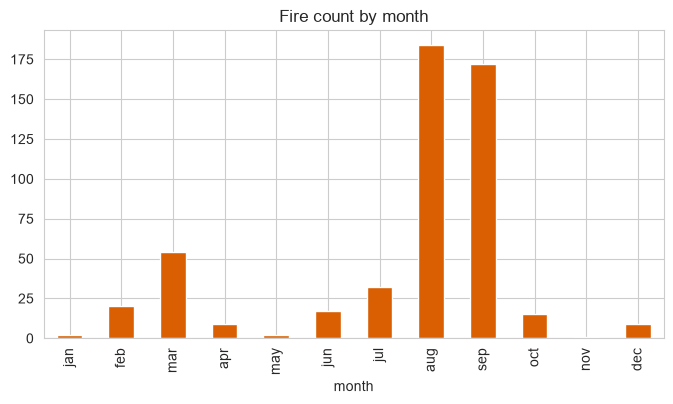

In [47]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
data['month'].value_counts().reindex(month_order).plot(kind='bar', color='#d95f02', figsize=(8,4))
plt.title("Fire count by month")
plt.show()

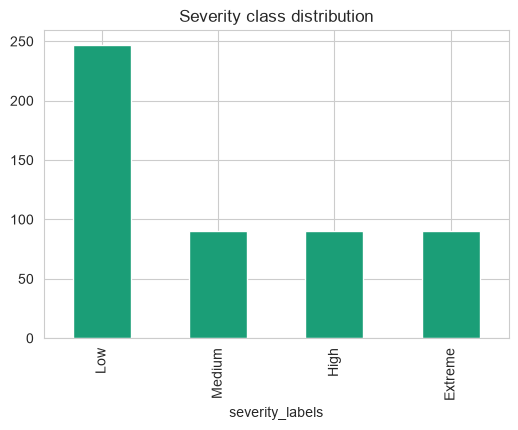

In [48]:
data['severity_labels'].value_counts().reindex(['Low','Medium','High','Extreme']).plot(kind='bar', color='#1b9e77', figsize=(6,4))
plt.title("Severity class distribution")
plt.show()

## Insights
- Fires cluster heavily in August/September making up 68.9% of all reported fires this is consitent with portugals dry season. an early warning system should weigh resources towards these two months rather than distrubuiting them equally
- sunday is the busiest day with 95 fires and weekends sat+ sun show higher fire spread aswell possibly representing higher park visitation and slower response times outside of typical work times
 - 47.8% of all reported fires burn 0 ha which means they were contained before spreading
  - fires that do spread on average burn 24.6 ha
    - there is a large distribution as the largest single fire burned 1090 HA, this gap between the typical fire and the worst case makes single point area predictions a weak   target
    - because of this ive decided a categorical severity scale would be more useful operationally

- raw weather data and FWI features correlate weakly with 'area' directly (max - 0.10) this is a known property of the dataset it does not mean that those features are uninformative  it just means that burned area more directly correlates to features unrecorded in this dataset such as response time, terrain or the exact ignition point not just the conditions at the time
- Fires are not evenly spread across the park a small number of grid cells (x=8,y=6) account for 52 fires suggesting that spatial facotors like maybe access routes (trails or lookouts) or something like vegatiation type  would be worth including as model features alongside weather conditions
-

## Task 2: Predictive Modelling and resource allocation


Encoding categoricals on a copy so that "data" in the previous cells keeps human readable month and day labels for reference


In [49]:
model_data = data.copy()

le_month = LabelEncoder()
le_day = LabelEncoder()
model_data['month_encoded'] = le_month.fit_transform(model_data['month'])
model_data['day_encoded'] = le_day.fit_transform(model_data['day'])

model_data = pd.get_dummies(model_data, columns=['month', 'day'], drop_first=True)
model_data.columns.tolist()

['X',
 'Y',
 'FFMC',
 'DMC',
 'DC',
 'ISI',
 'temp',
 'RH',
 'wind',
 'rain',
 'area',
 'area_log',
 'severity_labels',
 'month_encoded',
 'day_encoded',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'day_mon',
 'day_sat',
 'day_sun',
 'day_thu',
 'day_tue',
 'day_wed']

Resource allocation column (conducted research to see what the appropriate response would be to each tier of severity) (the numbers in the severity labels column represent the place of the first instance of each tier not the amount in each tier)



In [50]:
allocation_map = {
    'Low':     'Tier 1 - Monitor: 1 crew, routine patrol',
    'Medium':  'Tier 2 - Respond: 2-3 crews + engine',
    'High':    'Tier 3 - Escalate: strike team + air support',
    'Extreme': 'Tier 4 - Major incident: multi-agency + evacuation',
}
model_data['resource_allocation'] = model_data['severity_labels'].map(allocation_map)
model_data[['severity_labels', 'resource_allocation']].drop_duplicates()

,severity_labels,resource_allocation
0,Low,"Tier 1 - Monitor: 1 crew, routine patrol"
138,Medium,Tier 2 - Respond: 2-3 crews + engine
174,High,Tier 3 - Escalate: strike team + air support
196,Extreme,Tier 4 - Major incident: multi-agency + evacua...


## test train split


In [51]:

feature_cols = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind',
                 'rain', 'month_encoded', 'day_encoded']

X = model_data[feature_cols]
y = model_data['severity_labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(387, 12) (130, 12)
severity_labels
Low        185
Extreme     68
Medium      67
High        67
Name: count, dtype: int64


## random forest
no scaling needed as tree splits dont care about feature magnitude.

class_weight='balanced' lets the RF know to weigh and value rare classes like high and extreme severities higher during training


In [52]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))

=== Random Forest ===
Accuracy: 0.34615384615384615
              precision    recall  f1-score   support

     Extreme       0.23      0.23      0.23        22
        High       0.09      0.09      0.09        23
         Low       0.57      0.56      0.57        62
      Medium       0.12      0.13      0.13        23

    accuracy                           0.35       130
   macro avg       0.25      0.25      0.25       130
weighted avg       0.35      0.35      0.35       130



## Support vector machine
SVM does require scaling as it works on distance so a feature like DC with a range of 0-800 would overule a feature like ISI with a range of 0-60 if left unscaled


In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', random_state=RANDOM_STATE, class_weight='balanced')
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_proba = svm.predict_proba(X_test_scaled)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))

AttributeError: This 'SVC' has no attribute 'predict_proba'

## SMOTE (synthetic minority oversampling technique)
implementing smote to help try and improve Random Forest accuracy due to low number of rare classes



In [ ]:

sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_sm = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_sm.fit(X_train_sm, y_train_sm)
pred_sm = rf_sm.predict(X_test)

print("SMOTE-balanced RF:")
print(classification_report(y_test, pred_sm, zero_division=0))

## Confusion Martices ( random forest )


In [ ]:
classes = rf.classes_
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)

cm = confusion_matrix(y_test, pred, labels=classes)
plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title("Confusion matrix - Random Forest (severity)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

## AUC_ROC (random forest)
mutliple classes require one vs rest + lable bn

In [ ]:
y_test_bin = label_binarize(y_test, classes=classes)
auc_macro = roc_auc_score(y_test_bin, proba, average='macro', multi_class='ovr')
print(f"Macro AUC-ROC (one-vs-rest): {auc_macro:.3f}")

# per class breakdown is more informative than the single macro number
for i, c in enumerate(classes):
    auc_c = roc_auc_score(y_test_bin[:, i], proba[:, i])
    print(f"  {c}: {auc_c:.3f}")

## confusion matrices (SVM)


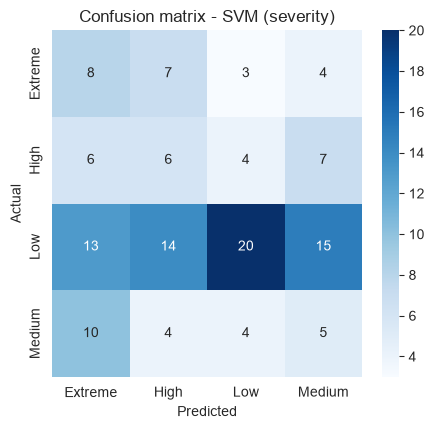

In [54]:

classes = svm.classes_
cm_svm = confusion_matrix(y_test, svm_pred, labels=classes)
plt.figure(figsize=(5, 4.5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion matrix - SVM (severity)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

## AUC_ROC (SVM)

In [ ]:
y_test_bin = label_binarize(y_test, classes=classes)
auc_macro_svm = roc_auc_score(y_test_bin, svm_proba, average='macro', multi_class='ovr')
print(f"SVM Macro AUC-ROC: {auc_macro_svm:.3f}")
for i, c in enumerate(classes):
    auc_c = roc_auc_score(y_test_bin[:, i], svm_proba[:, i])
    print(f"  {c}: {auc_c:.3f}")

In [ ]:
model_data['resource_allocation'].value_counts()


## Task 3 evaluation and bias


### 3.1 Comparing random forest and SVM

| Metric | Random Forest | SVM |
|---|---|---|
| Accuracy | 0.35 | 0.30 |
| Macro F1 | 0.18 | 0.28 |
| Macro AUC-ROC | 0.511 | 0.526 |

Random Forest produced higher raw accuracy, but this is caused pretty much solely by strong performance on the majority 'Low' class (recall 0.56) it widely fails on the rarer classes (`High` recall 0.09, `Extreme` recall 0.23).
SVM trades overall accuracy for a more balanced performance across the different classes it doubles it peforms more than twice aswell as RF when it comes to 'High' class more than doubling its recall ( 0.26 vs 0.09) and improving 'Extreme' recall (0.36 vs 0.23).

For a disaster response system designmed to help with resource allocation I would argue that SVM would be the more operationally useful model despite its lower headline accuracy
since the cost of missing a severe fire is far higher than the cost of a false alarm on a minor one.

however AUC-ROC indicates something different f1 and recall can be affect by the classification threshold and class_weight='balanced' may increase recall for rare classes without improving the models actual ability to distinguish them. AUC-ROC is independent of teh classification threshold so it helps to give us a better measure of the models underlying predictive ability
using AUC-ROC,RF and SVM perform similarly overall(0.511 vs 0.526). both models are also close to .5 for chance level for every class except 'Low'. this suggests that neither model have found strong patterns to distinguish medium, high and extereme severity. this means that SVM's better results for rare classes may be partly due to its decision threshold rather than some stronger predictive ability

## 3.2 attempting to improve reliability (smote)

SMOTE (synthetic minority oversampling technique)
Smote was tested to see if a rebalacing of the training data could help to improve rare class detection

| | Macro F1 | Macro AUC-ROC |
|---|---|---|
| Baseline RF | 0.18 | 0.511 |
| SMOTE RF | 0.22 | 0.505 |

SMOTE produced a real but modest F1 improvemetn and essentially no change to AUC-ROC this result is consistent with the above findings, SMOTE can rebalance how often the model guesses each class which influens F1 but it cannot create any meaningful discriminating signal that isnt already present in the data since we only havc 67-90 real examples per severity class, this is more of a data volume cieling rather than an algorithim or tuning problem

### 3.3 Potential biases and fairness impact

- **Class Imbalance** 247 low cs 90 each of the higher severity means the model sees fewer examples of the rarer higher stakes firesit would need to correctly indentify them. we see this taking place in the AUC0ROC scores above.
- **geographic biases** all of the above data stems from one park (monteseinho, portugal) from 2000 - 2003, vegetation climate and fire behaviour can greatly differ in a different geographical setting. for this model to be implemented elsewhere it would need revalidation before it was put to use
- **lack of socioeconomic or casualty data**  the severity scale is built purely upon area burned and contains nothing like casualty, evacuations or economic damage two fires of equal size copuld habe very different consequences depending on the location of the fire a real deployment of this model would need to have a population or assest layer before allocating resources
- **risk of over trusting** a severity label provided confidently by a dashboard could affect an emergency dispatcher judgement even in the high and extrem classifucation where this modelks weakness lies
-
-

### 3.4 strategies to improve reliability and mitigate bias
- **Collecting more severe fire samples over time** rathert than relying on synthetics oversampling, SMOTES improvement here suggests that real additional data is needed to meaningfully impoove rare class detection
- **Report model confidnce alongside the severity label** not justy the predicted class so that when the predicition is provided, dispatchers can see when a high/extreme prediction is borderline rather than presenting all predictions with equal apparent certainty. this is especially important considering the near chanfe auc - roc scores for those classes
- **add a population/asset layer** before using this approach for real world resource allocation in populated areas
- **validate on local data before a geographical transfer** this model would need retraining or atleast revalidation with an areas historical data before being implemented in that area
- **keeping a human in the process** the output from this model should be treated as decision suppoirt for a dispatcher not an automated allocation system particulary for the high and extreme tiers where the modesl reliability has been shown to be the weakest